In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from catboost import CatBoostClassifier

In [2]:
datas = pd.read_csv("missense_mutations.csv")

In [3]:
datas

,#AlleleID,Type,Name,GeneID,GeneSymbol,HGNC_ID,ClinicalSignificance,ClinSigSimple,LastEvaluated,RS# (dbSNP),...,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity,SCVsForAggregateGermlineClassification,SCVsForAggregateSomaticClinicalImpact,SCVsForAggregateOncogenicityClassification
0,24368,single nucleotide variant,NM_000059.4(BRCA2):c.1114A>C (p.Asn372His),675,BRCA2,HGNC:1101,Benign,0,"Jan 12, 2015",144848,...,C,-,-,-,-,-,-,SCV000245002,-,-
1,24368,single nucleotide variant,NM_000059.4(BRCA2):c.1114A>C (p.Asn372His),675,BRCA2,HGNC:1101,Benign,0,"Jan 12, 2015",144848,...,C,-,-,-,-,-,-,SCV000245002,-,-
2,24379,single nucleotide variant,NM_000059.4(BRCA2):c.8165C>G (p.Thr2722Arg),675,BRCA2,HGNC:1101,Pathogenic,1,"Aug 10, 2015",80359062,...,G,-,-,-,-,-,-,SCV000244480,-,-
3,24379,single nucleotide variant,NM_000059.4(BRCA2):c.8165C>G (p.Thr2722Arg),675,BRCA2,HGNC:1101,Pathogenic,1,"Aug 10, 2015",80359062,...,G,-,-,-,-,-,-,SCV000244480,-,-
4,24384,single nucleotide variant,NM_000059.4(BRCA2):c.7529T>C (p.Leu2510Pro),675,BRCA2,HGNC:1101,Pathogenic/Likely pathogenic,1,"Jul 09, 2024",80358979,...,C,-,-,-,-,-,-,SCV000567107|SCV000607817|SCV001478276|SCV0015...,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11229,4185255,single nucleotide variant,NM_000059.4(BRCA2):c.8754G>C (p.Glu2918Asp),675,BRCA2,HGNC:1101,Likely pathogenic,1,"Jun 12, 2025",-1,...,C,-,-,-,-,-,-,SCV006298678,-,-
11230,4198803,single nucleotide variant,NM_000059.4(BRCA2):c.1307A>G (p.Lys436Arg),675,BRCA2,HGNC:1101,Uncertain significance,0,-,-1,...,G,-,-,-,-,-,-,SCV006333499,-,-
11231,4198803,single nucleotide variant,NM_000059.4(BRCA2):c.1307A>G (p.Lys436Arg),675,BRCA2,HGNC:1101,Uncertain significance,0,-,-1,...,G,-,-,-,-,-,-,SCV006333499,-,-
11232,4391609,single nucleotide variant,NM_007294.4(BRCA1):c.298G>C (p.Glu100Gln),672,BRCA1,HGNC:1100,Uncertain significance,0,"Jul 31, 2025",-1,...,G,-,-,-,-,-,-,SCV006554521,-,-


In [4]:
# Çıkarılacak sütun listesi
drop_cols = [
    '#AlleleID', 'GeneID', 'HGNC_ID', 'RS# (dbSNP)', 
    'LastEvaluated', 'SomaticClinicalImpact', 
    'SomaticClinicalImpactLastEvaluated', 'ReviewStatusClinicalImpact',
    'Oncogenicity', 'OncogenicityLastEvaluated', 
    'ReviewStatusOncogenicity', 'ClinSigSimple','OtherIDs',
]

# SCV ile başlayan tüm aggregate sütunların seçilmesi 
scv_cols = [col for col in datas.columns if col.startswith('SCVsFor')]
drop_cols.extend(scv_cols)

# Sütunları temizle işlemi
datas_cleaned = datas.drop(columns=drop_cols)

print(f"Kalan Sütun Sayısı: {len(datas_cleaned.columns)}")

Kalan Sütun Sayısı: 27


In [5]:
datas_cleaned

,Type,Name,GeneSymbol,ClinicalSignificance,nsv/esv (dbVar),RCVaccession,PhenotypeIDS,PhenotypeList,Origin,OriginSimple,...,Cytogenetic,ReviewStatus,NumberSubmitters,Guidelines,TestedInGTR,SubmitterCategories,VariationID,PositionVCF,ReferenceAlleleVCF,AlternateAlleleVCF
0,single nucleotide variant,NM_000059.4(BRCA2):c.1114A>C (p.Asn372His),BRCA2,Benign,-,RCV000130720|RCV000320173|RCV000207052|RCV0002...,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary cancer-predisposing syndrome|Heredi...,germline;unknown,germline,...,13q13.1,reviewed by expert panel,39,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,3,9329,32906729,A,C
1,single nucleotide variant,NM_000059.4(BRCA2):c.1114A>C (p.Asn372His),BRCA2,Benign,-,RCV000130720|RCV000320173|RCV000207052|RCV0002...,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary cancer-predisposing syndrome|Heredi...,germline;unknown,germline,...,13q13.1,reviewed by expert panel,39,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,3,9329,32332592,A,C
2,single nucleotide variant,NM_000059.4(BRCA2):c.8165C>G (p.Thr2722Arg),BRCA2,Pathogenic,-,RCV000405476|RCV000031723|RCV000163026|RCV0011...,"MedGen:CN239275|MONDO:MONDO:0012933,MedGen:C26...","BRCA2-related disorder|Breast-ovarian cancer, ...",germline;maternal;unknown,germline,...,13q13.1,reviewed by expert panel,22,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,3,9340,32937504,C,G
3,single nucleotide variant,NM_000059.4(BRCA2):c.8165C>G (p.Thr2722Arg),BRCA2,Pathogenic,-,RCV000405476|RCV000031723|RCV000163026|RCV0011...,"MedGen:CN239275|MONDO:MONDO:0012933,MedGen:C26...","BRCA2-related disorder|Breast-ovarian cancer, ...",germline;maternal;unknown,germline,...,13q13.1,reviewed by expert panel,22,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,3,9340,32363367,C,G
4,single nucleotide variant,NM_000059.4(BRCA2):c.7529T>C (p.Leu2510Pro),BRCA2,Pathogenic/Likely pathogenic,-,RCV000009936|RCV000113772|RCV000478444|RCV0012...,"MONDO:MONDO:0011584,MedGen:C1838457,OMIM:60572...",Fanconi anemia complementation group D1|Breast...,germline,germline,...,13q13.1,"criteria provided, multiple submitters, no con...",11,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,3,9345,32930658,T,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11229,single nucleotide variant,NM_000059.4(BRCA2):c.8754G>C (p.Glu2918Asp),BRCA2,Likely pathogenic,-,RCV005621781,"MONDO:MONDO:0012933,MedGen:C2675520,OMIM:61255...","Breast-ovarian cancer, familial, susceptibilit...",unknown,unknown,...,13q13.1,"criteria provided, single submitter",1,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,2,4071408,32376791,G,C
11230,single nucleotide variant,NM_000059.4(BRCA2):c.1307A>G (p.Lys436Arg),BRCA2,Uncertain significance,-,RCV005645928,"MONDO:MONDO:0012933,MedGen:C2675520,OMIM:61255...","Breast-ovarian cancer, familial, susceptibilit...",germline,germline,...,13q13.1,"criteria provided, single submitter",1,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,2,4086110,32906922,A,G
11231,single nucleotide variant,NM_000059.4(BRCA2):c.1307A>G (p.Lys436Arg),BRCA2,Uncertain significance,-,RCV005645928,"MONDO:MONDO:0012933,MedGen:C2675520,OMIM:61255...","Breast-ovarian cancer, familial, susceptibilit...",germline,germline,...,13q13.1,"criteria provided, single submitter",1,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,2,4086110,32332785,A,G
11232,single nucleotide variant,NM_007294.4(BRCA1):c.298G>C (p.Glu100Gln),BRCA1,Uncertain significance,-,RCV005862042,"MONDO:MONDO:0011450,MedGen:C2676676,OMIM:60437...","Breast-ovarian cancer, familial, susceptibilit...",germline,germline,...,17q21.31,"criteria provided, single submitter",1,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,2,4279061,41256888,C,G


In [6]:
# '-' karakterlerini gerçek NaN ile değiştirme işlemi
datas_cleaned.replace('-', np.nan, inplace=True)

# Boş Sütunların görülmesi işlemi
print(datas_cleaned.isnull().sum())

Type                        0
Name                        0
GeneSymbol                  0
ClinicalSignificance     2222
nsv/esv (dbVar)         11234
RCVaccession                0
PhenotypeIDS                0
PhenotypeList               0
Origin                      0
OriginSimple                0
Assembly                    0
ChromosomeAccession         0
Chromosome                  0
Start                       0
Stop                        0
ReferenceAllele             0
AlternateAllele             0
Cytogenetic                 0
ReviewStatus             2222
NumberSubmitters            0
Guidelines                  0
TestedInGTR                 0
SubmitterCategories         0
VariationID                 0
PositionVCF                 0
ReferenceAlleleVCF          0
AlternateAlleleVCF          0
dtype: int64


C:\Users\emirh\AppData\Local\Temp\ipykernel_3368\3185353490.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datas_cleaned.replace('-', np.nan, inplace=True)


In [7]:
# 1. %90'dan fazlası boş olan sütunları otomatik silme işlemi
datas_cleaned.drop(columns=['nsv/esv (dbVar)'], inplace=True)

# 2. Hedef değişkeni (target) boş olan satırlardan silinmesi
datas_cleaned.dropna(subset=['ClinicalSignificance'], inplace=True)
datas_cleaned.dropna(subset=['ReviewStatus'], inplace=True)
# Diğer küçük boşluklar için (OtherIDs vb.)
datas_cleaned.fillna('Not_Available', inplace=True)

print(f"Temizlik sonrası veri boyutu: {datas_cleaned.shape}")

Temizlik sonrası veri boyutu: (9012, 26)


In [8]:
# '-' karakterlerini gerçek NaN değerlerine çevir
datas_cleaned.replace('-', np.nan, inplace=True)

# Hangi sütunda ne kadar boş var gör
print(datas_cleaned.isnull().sum())

Type                    0
Name                    0
GeneSymbol              0
ClinicalSignificance    0
RCVaccession            0
PhenotypeIDS            0
PhenotypeList           0
Origin                  0
OriginSimple            0
Assembly                0
ChromosomeAccession     0
Chromosome              0
Start                   0
Stop                    0
ReferenceAllele         0
AlternateAllele         0
Cytogenetic             0
ReviewStatus            0
NumberSubmitters        0
Guidelines              0
TestedInGTR             0
SubmitterCategories     0
VariationID             0
PositionVCF             0
ReferenceAlleleVCF      0
AlternateAlleleVCF      0
dtype: int64


In [9]:
datas_cleaned

,Type,Name,GeneSymbol,ClinicalSignificance,RCVaccession,PhenotypeIDS,PhenotypeList,Origin,OriginSimple,Assembly,...,Cytogenetic,ReviewStatus,NumberSubmitters,Guidelines,TestedInGTR,SubmitterCategories,VariationID,PositionVCF,ReferenceAlleleVCF,AlternateAlleleVCF
0,single nucleotide variant,NM_000059.4(BRCA2):c.1114A>C (p.Asn372His),BRCA2,Benign,RCV000130720|RCV000320173|RCV000207052|RCV0002...,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary cancer-predisposing syndrome|Heredi...,germline;unknown,germline,GRCh37,...,13q13.1,reviewed by expert panel,39,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,3,9329,32906729,A,C
1,single nucleotide variant,NM_000059.4(BRCA2):c.1114A>C (p.Asn372His),BRCA2,Benign,RCV000130720|RCV000320173|RCV000207052|RCV0002...,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary cancer-predisposing syndrome|Heredi...,germline;unknown,germline,GRCh38,...,13q13.1,reviewed by expert panel,39,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,3,9329,32332592,A,C
2,single nucleotide variant,NM_000059.4(BRCA2):c.8165C>G (p.Thr2722Arg),BRCA2,Pathogenic,RCV000405476|RCV000031723|RCV000163026|RCV0011...,"MedGen:CN239275|MONDO:MONDO:0012933,MedGen:C26...","BRCA2-related disorder|Breast-ovarian cancer, ...",germline;maternal;unknown,germline,GRCh37,...,13q13.1,reviewed by expert panel,22,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,3,9340,32937504,C,G
3,single nucleotide variant,NM_000059.4(BRCA2):c.8165C>G (p.Thr2722Arg),BRCA2,Pathogenic,RCV000405476|RCV000031723|RCV000163026|RCV0011...,"MedGen:CN239275|MONDO:MONDO:0012933,MedGen:C26...","BRCA2-related disorder|Breast-ovarian cancer, ...",germline;maternal;unknown,germline,GRCh38,...,13q13.1,reviewed by expert panel,22,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,3,9340,32363367,C,G
4,single nucleotide variant,NM_000059.4(BRCA2):c.7529T>C (p.Leu2510Pro),BRCA2,Pathogenic/Likely pathogenic,RCV000009936|RCV000113772|RCV000478444|RCV0012...,"MONDO:MONDO:0011584,MedGen:C1838457,OMIM:60572...",Fanconi anemia complementation group D1|Breast...,germline,germline,GRCh37,...,13q13.1,"criteria provided, multiple submitters, no con...",11,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,3,9345,32930658,T,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11229,single nucleotide variant,NM_000059.4(BRCA2):c.8754G>C (p.Glu2918Asp),BRCA2,Likely pathogenic,RCV005621781,"MONDO:MONDO:0012933,MedGen:C2675520,OMIM:61255...","Breast-ovarian cancer, familial, susceptibilit...",unknown,unknown,GRCh38,...,13q13.1,"criteria provided, single submitter",1,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,2,4071408,32376791,G,C
11230,single nucleotide variant,NM_000059.4(BRCA2):c.1307A>G (p.Lys436Arg),BRCA2,Uncertain significance,RCV005645928,"MONDO:MONDO:0012933,MedGen:C2675520,OMIM:61255...","Breast-ovarian cancer, familial, susceptibilit...",germline,germline,GRCh37,...,13q13.1,"criteria provided, single submitter",1,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,2,4086110,32906922,A,G
11231,single nucleotide variant,NM_000059.4(BRCA2):c.1307A>G (p.Lys436Arg),BRCA2,Uncertain significance,RCV005645928,"MONDO:MONDO:0012933,MedGen:C2675520,OMIM:61255...","Breast-ovarian cancer, familial, susceptibilit...",germline,germline,GRCh38,...,13q13.1,"criteria provided, single submitter",1,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,2,4086110,32332785,A,G
11232,single nucleotide variant,NM_007294.4(BRCA1):c.298G>C (p.Glu100Gln),BRCA1,Uncertain significance,RCV005862042,"MONDO:MONDO:0011450,MedGen:C2676676,OMIM:60437...","Breast-ovarian cancer, familial, susceptibilit...",germline,germline,GRCh37,...,17q21.31,"criteria provided, single submitter",1,"ACMG2013,ACMG2016,ACMG2021,ACMG2022",N,2,4279061,41256888,C,G


Veri tekrarının ortadan kaldrılması.

In [10]:
datas_cleaned = datas_cleaned[datas_cleaned['Assembly'] == 'GRCh38'].copy()

In [11]:
# Örn: NM_000059.4(BRCA2):c.1114A>C (p.Asn372His)
# 1. Nükleotid Pozisyonunu çekilmesi (1114)
datas_cleaned['nuc_pos'] = datas_cleaned['Name'].str.extract(r'c\.(\d+)').astype(float)

# 2. Değişim tipini çekilmesi (A > C)
datas_cleaned['ref_nuc'] = datas_cleaned['Name'].str.extract(r'c\.\d+([A-Z])')
datas_cleaned['alt_nuc'] = datas_cleaned['Name'].str.extract(r'>([A-Z])')

# 3. Protein değişim pozisyonunu çekilmesi (372)
datas_cleaned['prot_pos'] = datas_cleaned['Name'].str.extract(r'p\.[A-Za-z]+(\d+)').astype(float)

In [12]:
def label_simplifier(sig):
    sig = str(sig).lower()
    if 'pathogenic' in sig:
        return 1
    elif 'benign' in sig:
        return 0
    else:
        return None # Uncertain olanları elemek için

datas_cleaned['target'] = datas_cleaned['ClinicalSignificance'].apply(label_simplifier)

# Etiketi olmayan (Uncertain/NaN) satırları veri setinden çıkarılması
datas_cleaned.dropna(subset=['target'], inplace=True)

In [13]:
# Sınıflandırma yapabilmek için metinleri 0 ve 1'e çeviriyoruz
target_mapping = {
    'Benign': 0, 
    'Likely benign': 0,
    'Pathogenic': 1, 
    'Likely pathogenic': 1, 
    'Pathogenic/Likely pathogenic': 1
}

datas_cleaned['target'] = datas_cleaned['ClinicalSignificance'].map(target_mapping)

# Belirsiz (Uncertain) veya haritalanmamış satırları eliyoruz
datas_cleaned = datas_cleaned.dropna(subset=['target'])
y = datas_cleaned['target'].astype(int)


# 'Name' sütunundaki c.1114A>C ifadesinden sayısal pozisyonu çekiyoruz
datas_cleaned['nuc_pos'] = datas_cleaned['Name'].str.extract(r'c\.(\d+)').astype(float)

# Modele sokacağımız anlamlı sütunları seçiyoruz
feature_columns =   ['Type', 'GeneSymbol', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']

#  0/1 matrisine çeviriyoruz
X = datas_cleaned[feature_columns] 
y = datas_cleaned['target'].astype(int)

print(f"X (Özellikler) tanımlandı: {X.shape[1]} adet sütun oluştu.")
print(f"y (Hedef) tanımlandı: {len(y)} adet etiket hazır.")

X (Özellikler) tanımlandı: 4 adet sütun oluştu.
y (Hedef) tanımlandı: 735 adet etiket hazır.


In [14]:
# 1. Ham sayıları görmek için
print("Sınıf Dağılımı (Sayı):")
print(y.value_counts())

# 2. Yüzdelik oranları görmek için
print("\nSınıf Dağılımı (Yüzde %):")
print(y.value_counts(normalize=True) * 100)

Sınıf Dağılımı (Sayı):
target
0    465
1    270
Name: count, dtype: int64

Sınıf Dağılımı (Yüzde %):
target
0    63.265306
1    36.734694
Name: proportion, dtype: float64


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
# Modeli tanımla
class_weight = 465 / 270
model_cat = CatBoostClassifier(
    iterations=500,           # Ağaç sayısı
    learning_rate=0.05,       # Öğrenme hızı 
    depth=4,                  # Derinlik (Overfitting engellemek için )
    scale_pos_weight=class_weight, 
    loss_function='Logloss',
    verbose=100,              # Her 100 adımda rapor 
    random_seed=42
)

# Eğitim
model_cat.fit(
    X_train, y_train, 
    cat_features=feature_columns,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50  # 50 adımda başarı artmazsa durdur
)
y_probs = model_cat.predict_proba(X_test)[:, 1]

0:	learn: 0.6914570	test: 0.6908763	best: 0.6908763 (0)	total: 167ms	remaining: 1m 23s
100:	learn: 0.6043486	test: 0.6100409	best: 0.6100409 (100)	total: 1.77s	remaining: 7s
200:	learn: 0.5690299	test: 0.6146211	best: 0.6082728 (150)	total: 3.47s	remaining: 5.17s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6082728154
bestIteration = 150

Shrink model to first 151 iterations.


--- CatBoost Performans Raporu ---
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        93
           1       0.60      0.59      0.60        54

    accuracy                           0.71       147
   macro avg       0.68      0.68      0.68       147
weighted avg       0.71      0.71      0.71       147



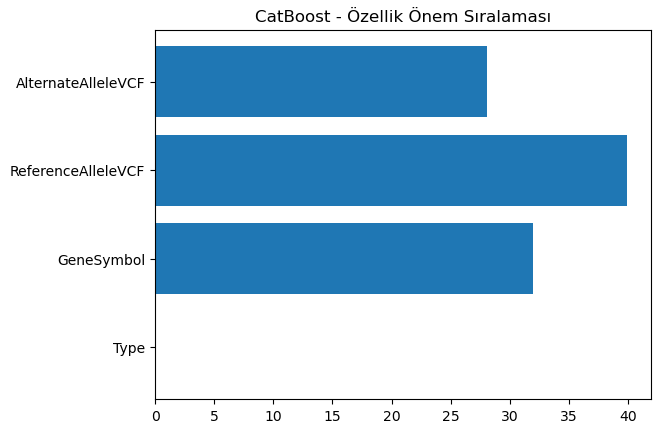

In [17]:
y_pred = model_cat.predict(X_test)

print("--- CatBoost Performans Raporu ---")
print(classification_report(y_test, y_pred))

# Özelliklerin önemini görselleştirme işlemi
feature_importance = model_cat.get_feature_importance()
plt.barh(X.columns, feature_importance)
plt.title("CatBoost - Özellik Önem Sıralaması")
plt.show()

In [18]:
# 1. Detaylı Metrik Raporu
print("--- Model Performans Raporu ---")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Pathogenic']))

# 2. ROC-AUC Skoru (Tahmin olasılıklarını kullanır)
auc = roc_auc_score(y_test, y_probs)
print(f"ROC-AUC Skoru: {auc:.4f}")

# confusion_matrix
print("\n--- Karmaşıklık Matrisi ---")
print(confusion_matrix(y_test, y_pred))

--- Model Performans Raporu ---
              precision    recall  f1-score   support

      Benign       0.77      0.77      0.77        93
  Pathogenic       0.60      0.59      0.60        54

    accuracy                           0.71       147
   macro avg       0.68      0.68      0.68       147
weighted avg       0.71      0.71      0.71       147

ROC-AUC Skoru: 0.7559

--- Karmaşıklık Matrisi ---
[[72 21]
 [22 32]]


## Grid Search Kullanımı